INFO: Loading processed data from C:\Users\gabst\data\silver\2024_silverstone_R_silver.parquet


C:\Users\gabst\AppData\Local\Temp\ipykernel_16052\911076752.py:42: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\gabst\AppData\Local\Temp\ipykernel_16052\911076752.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Tyre Compound', title_fontsize='12', loc='upper left')


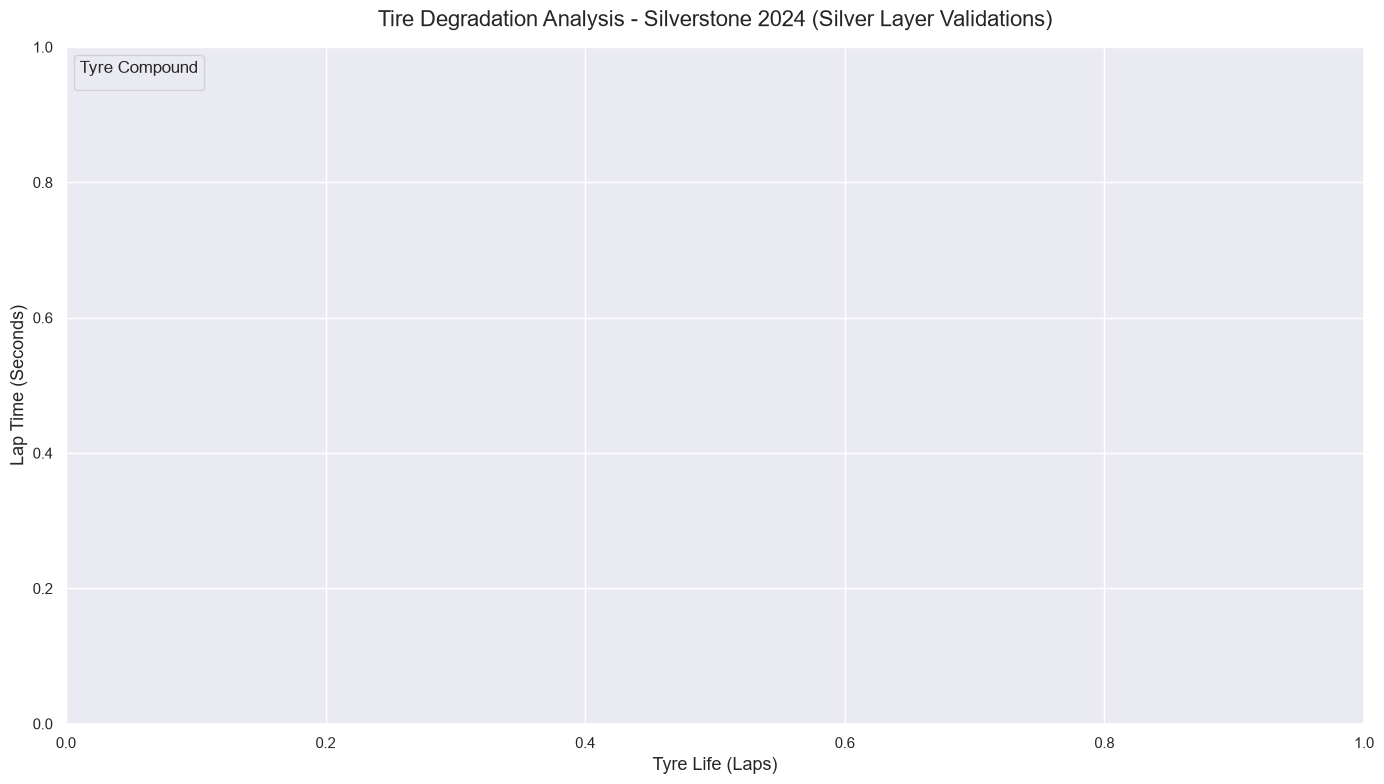

In [ ]:
"""
Module: Silver Layer Data Visualization
Description: Loads the processed Parquet data from the Silver layer into Pandas 
             to visualize tire degradation trends (Lap Time vs. Tyre Life) 
             using Seaborn, validating data quality before ML modeling.
"""

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Definir la ruta exacta al directorio particionado generado por PySpark
# Definir la ruta absoluta exacta donde Spark guardó los datos
SILVER_DIR = r"C:\Users\gabst\data\silver\2024_silverstone_R_silver.parquet"

def plot_tyre_degradation(file_path: str):
    """
    Loads the Silver layer dataset and generates a scatter plot to analyze 
    the degradation of different tire compounds over their lifespan.
    """
    print(f"INFO: Loading processed data from {file_path}")
    
    # Pandas natively supports reading Parquet directories via pyarrow
    df_silver = pd.read_parquet(file_path)
    
    # Data Quality & Outlier Filtering:
    # Laps under Safety Car, VSC, or Pit Stops will heavily distort the scale.
    # A standard race pace lap at Silverstone 2024 is roughly between 88 and 100 seconds.
    df_filtered = df_silver[(df_silver['LapTime'] > 85) & (df_silver['LapTime'] < 105)]
    
    # Filter for standard dry compounds only
    valid_compounds = ['SOFT', 'MEDIUM', 'HARD']
    df_filtered = df_filtered[df_filtered['Compound'].isin(valid_compounds)]
    
    # Initialize Seaborn aesthetic settings (dark background helps bright F1 colors pop)
    sns.set_theme(style="darkgrid")
    
    plt.figure(figsize=(14, 8))
    
    # Scatter plot mapping TyreLife to LapTime
    sns.scatterplot(
        data=df_filtered, 
        x='TyreLife', 
        y='LapTime', 
        hue='Compound', 
        palette={'SOFT': '#FF3333', 'MEDIUM': '#FFFF00', 'HARD': '#FFFFFF'}, # Official F1 Pirelli colors
        alpha=0.7,
        s=60,
        edgecolor="black"
    )
    
    # Adding titles and labels
    plt.title("Tire Degradation Analysis - Silverstone 2024 (Silver Layer Validations)", fontsize=16, pad=15)
    plt.xlabel("Tyre Life (Laps)", fontsize=13)
    plt.ylabel("Lap Time (Seconds)", fontsize=13)
    
    # Customize the legend
    plt.legend(title='Tyre Compound', title_fontsize='12', loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_tyre_degradation(SILVER_DIR)